# Análisis Exploratorio de Metadatos (EDA)
## Dataset EMG: sujetos intactos y amputados

Este notebook documenta el análisis exploratorio de los metadatos asociados al proyecto EMG. El objetivo es describir la composición de la muestra, revisar la distribución de las variables demográficas y antropométricas, y comparar el perfil general de sujetos intactos y amputados para contextualizar el análisis posterior de las señales.

La lectura está organizada como un informe técnico: primero se presenta el contexto del análisis, luego se estudia cada grupo por separado y finalmente se comparan ambos conjuntos para identificar diferencias relevantes.

### Variables revisadas
- Género
- Lateralidad
- Edad
- Peso
- Altura
- Base de datos de origen
- Causa de amputación
- Intensidad de la sensación de miembro fantasma
- Puntuación DASH

### Cómo leer este notebook
Cada subsección combina una breve explicación conceptual con tablas y gráficos. La intención es que el notebook pueda entenderse sin depender de contexto externo, dejando claro qué se analiza, por qué se analiza y qué aporta cada visualización.

## 1. Carga de librerías y datos

En esta sección se importan las librerías necesarias para el análisis y se cargan los archivos maestros con los metadatos de los dos grupos de estudio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
amputated = pd.read_csv('../data/master/amputated_subjects.csv')

## 3. Análisis descriptivo del grupo amputado

En esta sección se documenta el grupo amputado. Además de las variables demográficas y antropométricas, este conjunto incluye indicadores clínicos que ayudan a entender el estado funcional y la experiencia reportada por los sujetos.

#### 3.1 Resumen general

Se revisa la estructura del conjunto de datos amputado para identificar variables disponibles, tipos de dato y estadísticos básicos. Este paso permite anticipar qué variables serán útiles en la comparación con el grupo intacto.

In [2]:
amputated

,Subject,Hand,Handedness,Age,Height,Weight,Remaining Forearm (%),Years passed by the amputation,Amputation cause,Phantom Limb Sensation Intensity,DASH Score,Use of cosmetic prosthesis (Years),Use of kinematic prosthesis (Years),Use of myoelectric prosthesis (Years),Database,Gender
0,1,Right Hand Amputated,Right,32,172,86,50.0,13.0,Accident,2.0,1.67,0.0,0.00,13.0,DB3,Male
1,2,Left Hand Amputated,Right,35,183,81,70.0,6.0,Accident,5.0,15.18,6.0,0.00,0.0,DB3,Male
2,3,Right Hand Amputated,Right,50,178,82,30.0,5.0,Accident,2.0,22.50,0.0,8.00,8.0,DB3,Male
3,4,Right Hand Amputated,Right,34,166,68,40.0,1.0,Accident,1.0,86.67,0.0,0.00,0.0,DB3,Female
4,5,Left Hand Amputated,Left,67,175,75,90.0,1.0,Accident,2.0,11.67,0.0,0.40,0.0,DB3,Male
5,6,Left Hand Amputated,Right,32,172,66,40.0,13.0,Accident,4.0,37.50,0.0,12.00,0.0,DB3,Male
6,7,Right Hand Amputated,Right,35,185,75,0.0,7.0,Accident,0.0,31.67,0.0,0.00,6.0,DB3,Male
7,8,Right Hand Amputated,Right,33,175,80,50.0,5.0,Accident,2.0,33.33,0.0,0.00,4.0,DB3,Male
8,9,Right Hand Amputated,Right,44,180,95,90.0,14.0,Accident,5.0,3.33,0.0,0.00,14.0,DB3,Male
9,10,Right Hand Amputated,Right,59,177,86,50.0,2.0,Accident,5.0,11.67,0.0,1.66,0.0,DB3,Male


In [3]:
amputated.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Subject                                13 non-null     int64  
 1   Hand                                   13 non-null     str    
 2   Handedness                             13 non-null     str    
 3   Age                                    13 non-null     int64  
 4   Height                                 13 non-null     int64  
 5   Weight                                 13 non-null     int64  
 6   Remaining Forearm (%)                  13 non-null     float64
 7   Years passed by the amputation         13 non-null     float64
 8   Amputation cause                       13 non-null     str    
 9   Phantom Limb Sensation Intensity       11 non-null     float64
 10  DASH Score                             11 non-null     float64
 11  Use of cosmetic pro

In [4]:
amputated.describe() 

,Subject,Age,Height,Weight,Remaining Forearm (%),Years passed by the amputation,Phantom Limb Sensation Intensity,DASH Score,Use of cosmetic prosthesis (Years),Use of kinematic prosthesis (Years),Use of myoelectric prosthesis (Years)
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,11.000000,11.000000,13.000000,13.000000,13.000000
mean,8.384615,42.153846,177.538462,79.615385,53.846154,7.384615,2.909091,24.335455,0.461538,3.850769,4.000000
std,6.564278,12.157619,5.440824,8.322044,25.993096,5.408920,1.758098,23.867649,1.664101,5.538848,5.016639
min,1.000000,28.000000,166.000000,66.000000,0.000000,1.000000,0.000000,1.670000,0.000000,0.000000,0.000000
25%,4.000000,33.000000,175.000000,75.000000,40.000000,5.000000,2.000000,11.670000,0.000000,0.000000,0.000000
50%,7.000000,35.000000,178.000000,80.000000,50.000000,6.000000,2.000000,15.180000,0.000000,0.400000,2.000000
75%,10.000000,50.000000,182.000000,86.000000,70.000000,13.000000,4.500000,32.500000,0.000000,6.000000,6.000000
max,22.000000,67.000000,185.000000,95.000000,90.000000,18.000000,5.000000,86.670000,6.000000,17.000000,14.000000


##### 3.1.1 Valores faltantes en variables clínicas

Dos variables clínicas —intensidad de sensación de miembro fantasma y puntuación DASH— tienen 11 de 13 valores no nulos. Antes de analizarlas conviene dejar explícito cuántos y cuáles sujetos faltan, y revisar si ese faltante se concentra en alguna base de datos en particular.

In [5]:
faltantes = amputated[['Phantom Limb Sensation Intensity', 'DASH Score']].isna().sum()
print('Valores faltantes por variable:')
print(faltantes)

print('\nSujetos con algún dato clínico faltante:')
amputated[amputated[['Phantom Limb Sensation Intensity', 'DASH Score']].isna().any(axis=1)][['Subject', 'Database']]

Valores faltantes por variable:
Phantom Limb Sensation Intensity    2
DASH Score                          2
dtype: int64

Sujetos con algún dato clínico faltante:


,Subject,Database
11,21,DB7
12,22,DB7


#### 3.2 Variables categóricas

Aquí se analizan dos aspectos de composición del grupo amputado: género y causa de amputación. La primera variable aporta contexto demográfico y la segunda introduce una dimensión clínica clave para interpretar la heterogeneidad del conjunto.

Text(0.5, 1.0, 'Distribución del género - Grupo amputado (n=13)')

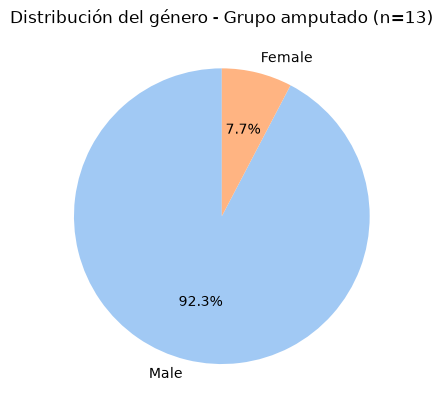

In [6]:
colores = sns.color_palette('pastel')
valores = amputated['Gender'].value_counts().values
etiquetas = amputated['Gender'].value_counts().index

plt.pie(valores, labels=etiquetas, colors=colores, autopct='%1.1f%%', startangle=90)
plt.title('Distribución del género - Grupo amputado (n=13)')


Text(0.5, 1.0, 'Distribución de la causa de amputación - Grupo amputado (n=13)')

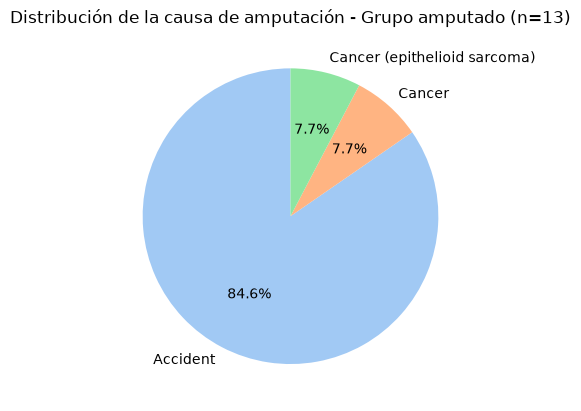

In [7]:
colores = sns.color_palette('pastel')
valores = amputated['Amputation cause'].value_counts().values
etiquetas = amputated['Amputation cause'].value_counts().index

plt.pie(valores, labels=etiquetas, colors=colores, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de la causa de amputación - Grupo amputado (n=13)')


##### 3.2.3 Distribución por base de datos

Al igual que en el grupo intacto, se revisa qué proporción de sujetos amputados proviene de cada base de datos. Con un total de apenas 13 sujetos, conviene tener presente que un único caso puede representar una porción importante del gráfico.


Text(0.5, 1.0, 'Porcentaje de sujetos por base de datos - Grupo amputado (n=13)')

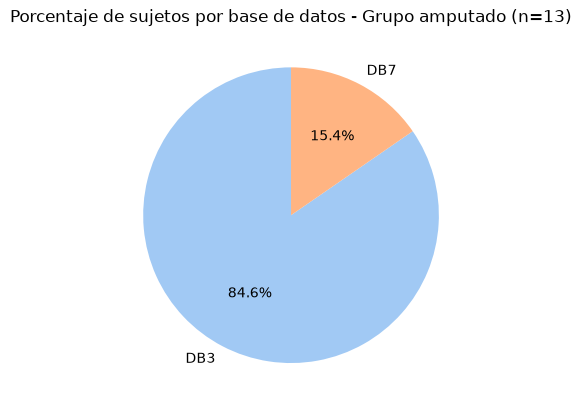

In [8]:
colores = sns.color_palette('pastel')
valores = amputated['Database'].value_counts().values
etiquetas = amputated['Database'].value_counts().index

plt.pie(valores, labels=etiquetas, colors=colores, autopct='%1.1f%%', startangle=90)
plt.title('Porcentaje de sujetos por base de datos - Grupo amputado (n=13)')


Text(0.5, 1.0, 'Porcentaje de sujetos por lateralidad - Grupo amputado (n=13)')

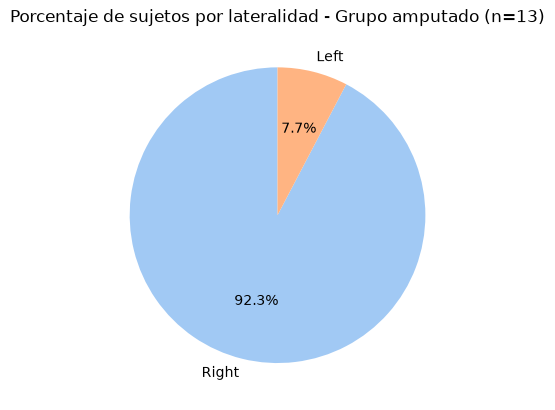

In [9]:
colores = sns.color_palette('pastel')
valores = amputated['Handedness'].value_counts().values
etiquetas = amputated['Handedness'].value_counts().index

plt.pie(valores, labels=etiquetas, colors=colores, autopct='%1.1f%%', startangle=90)
plt.title('Porcentaje de sujetos por lateralidad - Grupo amputado (n=13)')


In [10]:
pd.crosstab(amputated['Database'], amputated['Gender'])

Gender,Female,Male
Database,,
DB3,1,10
DB7,0,2


#### 3.3 Variables antropométricas

Edad, peso y altura se exploran por separado para describir el perfil físico del grupo amputado. Estas variables son especialmente relevantes porque condicionan comparaciones posteriores y ayudan a contextualizar la lectura de las señales y de las medidas clínicas.

Text(0, 0.5, 'Número de sujetos')

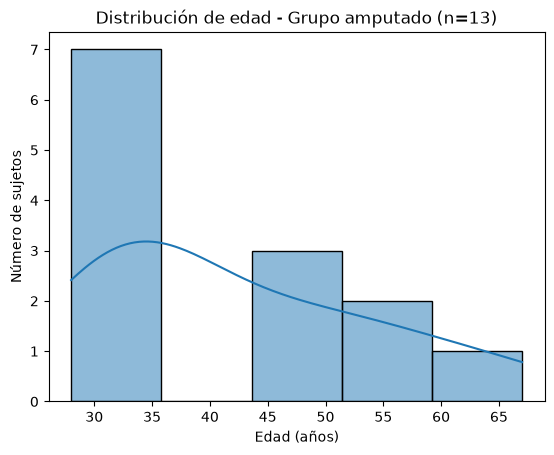

In [11]:
sns.histplot(amputated['Age'].values, kde=True)
plt.title('Distribución de edad - Grupo amputado (n=13)')
plt.xlabel('Edad (años)')
plt.ylabel('Número de sujetos')


Text(0, 0.5, 'Número de sujetos')

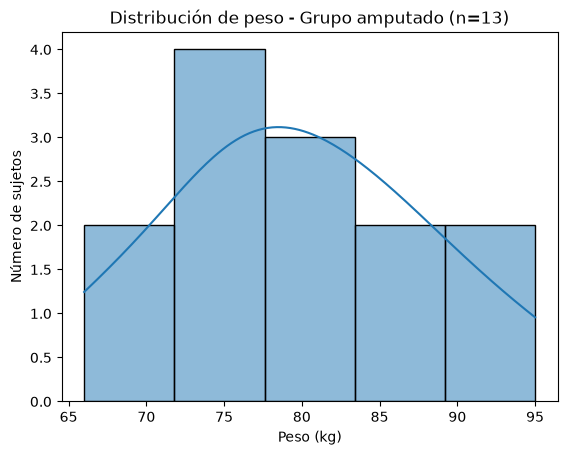

In [12]:
sns.histplot(amputated['Weight'].values, kde=True)
plt.title('Distribución de peso - Grupo amputado (n=13)')
plt.xlabel('Peso (kg)')
plt.ylabel('Número de sujetos')


Text(0, 0.5, 'Número de sujetos')

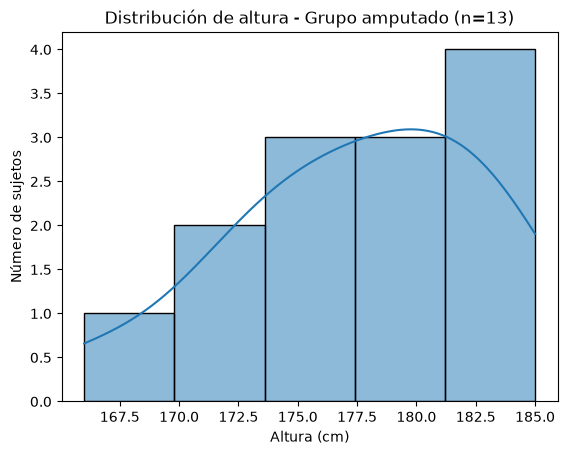

In [13]:
sns.histplot(amputated['Height'].values, kde=True)
plt.title('Distribución de altura - Grupo amputado (n=13)')
plt.xlabel('Altura (cm)')
plt.ylabel('Número de sujetos')


Text(0, 0.5, 'Densidad')

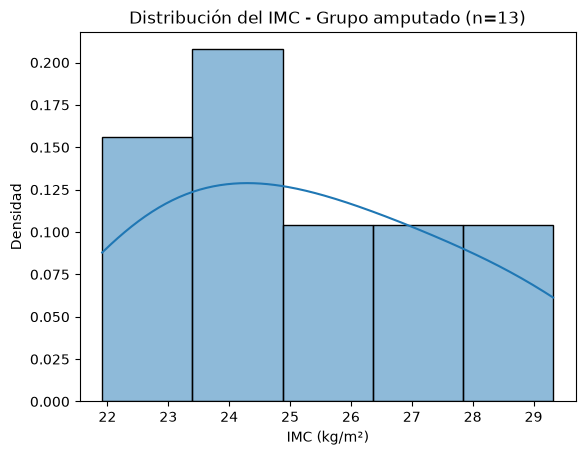

In [14]:
amputated['BMI'] = amputated['Weight'] / (amputated['Height'] / 100) ** 2
sns.histplot(amputated['BMI'], kde=True, stat='density')
plt.title('Distribución del IMC - Grupo amputado (n=13)')
plt.xlabel('IMC (kg/m²)')
plt.ylabel('Densidad')


Text(0.5, 1.0, 'Clasificación del IMC - Grupo amputado (n=13)')

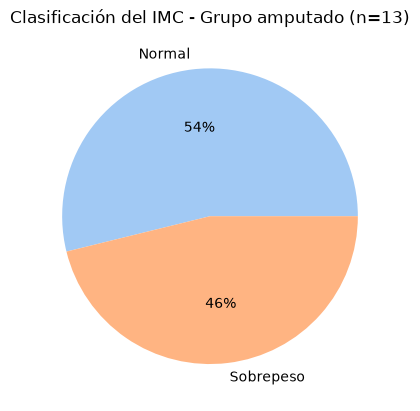

In [15]:
bins_imc = [0, 18.5, 25, 30, 100]
etiquetas_imc = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']

amputated['BMI Category'] = pd.cut(amputated['BMI'], bins=bins_imc, labels=etiquetas_imc)

colores = sns.color_palette('pastel')
conteo_imc = amputated['BMI Category'].value_counts()
conteo_imc = conteo_imc[conteo_imc > 0]  # elimina categorías con 0 sujetos

colores = sns.color_palette('pastel')
valores = conteo_imc.values
etiquetas = conteo_imc.index

plt.pie(valores, labels=etiquetas, colors=colores, autopct='%1.0f%%')
plt.title('Clasificación del IMC - Grupo amputado (n=13)')

La comparación por base de datos permite verificar si los subconjuntos de origen son comparables o si presentan perfiles distintos. Si existen diferencias marcadas, estas pueden influir en cualquier análisis agregado y conviene tenerlas presentes al interpretar el conjunto completo.

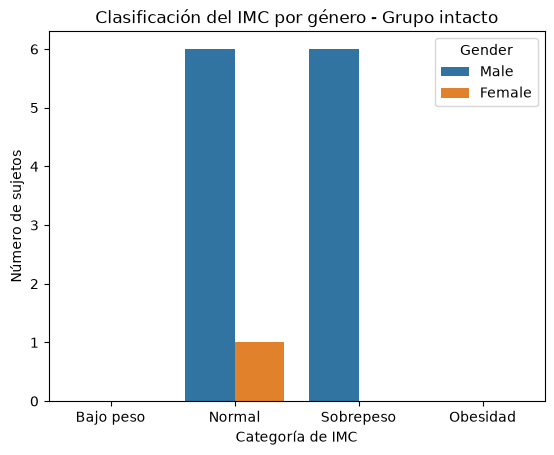

In [16]:
sns.countplot(data=amputated, x='BMI Category', hue='Gender')
plt.title('Clasificación del IMC por género - Grupo intacto')
plt.xlabel('Categoría de IMC')
plt.ylabel('Número de sujetos')
plt.show()

#### 3.4 Análisis estratificado por BMI

Este bloque compara edad, peso y altura entre categorías de IMC dentro del grupo amputado. El objetivo es identificar si el perfil antropométrico varía de forma apreciable entre los subgrupos Normal y Sobrepeso, y si la categoría de IMC resulta una variable relevante para estratificar análisis posteriores. Dado que la muestra amputada solo presenta dos categorías (Normal y Sobrepeso) y un tamaño reducido.

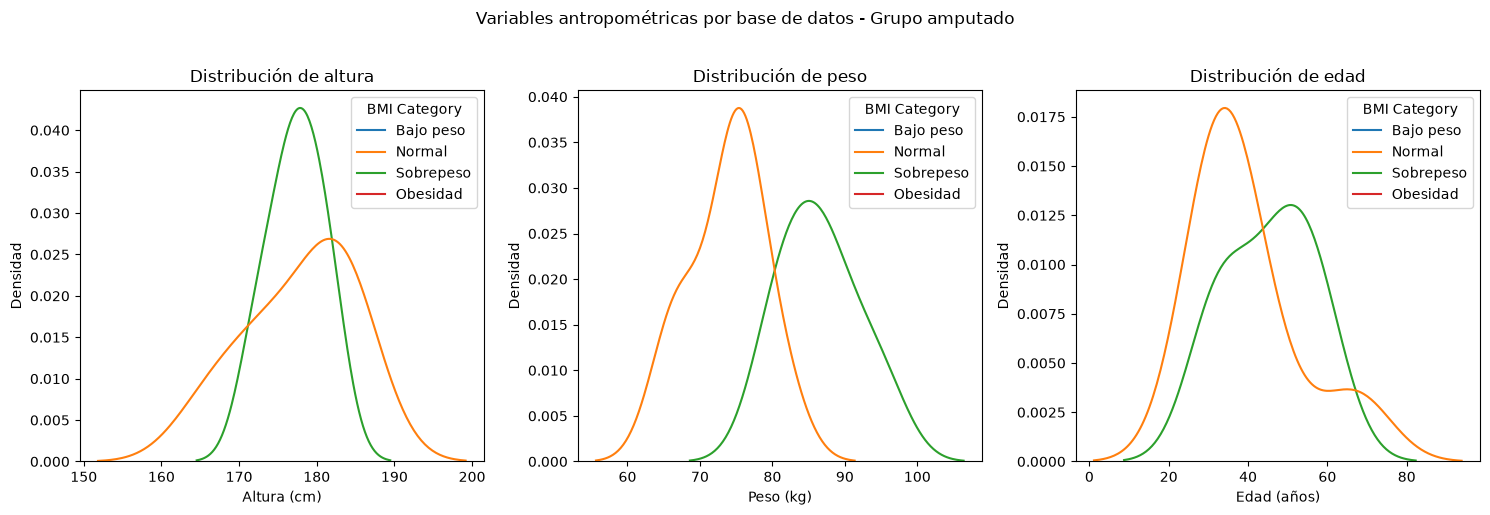

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=amputated, x='Height', hue='BMI Category', ax=axes[0])
axes[0].set_title('Distribución de altura')
axes[0].set_xlabel('Altura (cm)')
axes[0].set_ylabel('Densidad')

sns.kdeplot(data=amputated, x='Weight', hue='BMI Category', ax=axes[1])
axes[1].set_title('Distribución de peso')
axes[1].set_xlabel('Peso (kg)')
axes[1].set_ylabel('Densidad')

sns.kdeplot(data=amputated, x='Age', hue='BMI Category', ax=axes[2])
axes[2].set_title('Distribución de edad')
axes[2].set_xlabel('Edad (años)')
axes[2].set_ylabel('Densidad')

fig.suptitle('Variables antropométricas por base de datos - Grupo amputado', y=1.02)
plt.tight_layout()

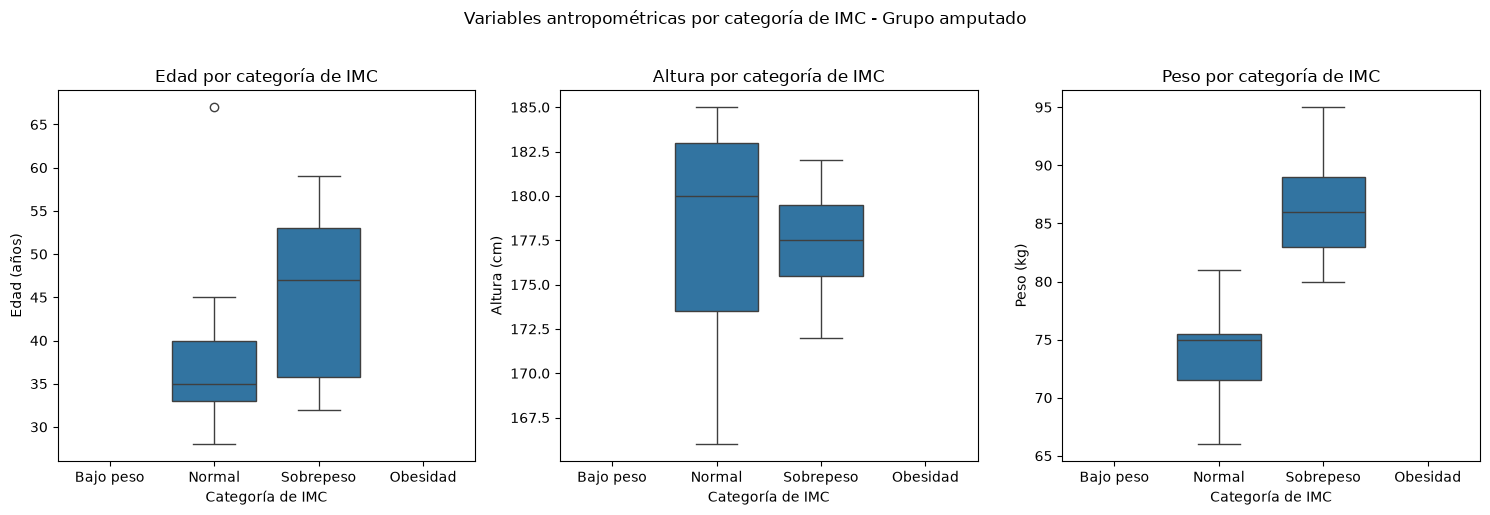

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='BMI Category', y='Age', data=amputated, ax=axes[0])
sns.boxplot(x='BMI Category', y='Height', data=amputated, ax=axes[1])
sns.boxplot(x='BMI Category', y='Weight', data=amputated, ax=axes[2])

unidades = {'Edad': 'años', 'Altura': 'cm', 'Peso': 'kg'}
for ax, titulo in zip(axes, ['Edad', 'Altura', 'Peso']):
    ax.set_title(f'{titulo} por categoría de IMC')
    ax.set_xlabel('Categoría de IMC')
    ax.set_ylabel(f'{titulo} ({unidades[titulo]})')

fig.suptitle('Variables antropométricas por categoría de IMC - Grupo amputado', y=1.02)
plt.tight_layout()

##### 3.4.1 Tabla resumen: media y desviación estándar por categoría de IMC - Grupo amputado

Esta tabla resume las variables antropométricas (edad, peso y altura) desglosadas por categoría de IMC dentro del grupo amputado. Dado que solo se presentan las categorías "Normal" y "Sobrepeso", la tabla permite contrastar el perfil físico entre ambos subgrupos. Es importante señalar que el tamaño de muestra es reducido (n=13), por lo que las medias y desviaciones estándar deben interpretarse como indicadores exploratorios y no como estimaciones robustas de la población.

In [19]:
resumen_amputados = amputated.groupby('BMI Category').agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_amputados

,n,Edad_media,Edad_de,Altura_media,Altura_de,Peso_media,Peso_de
BMI Category,,,,,,,
Normal,7,39.4,13.2,177.7,7.0,73.7,5.1
Sobrepeso,6,45.3,11.1,177.3,3.6,86.5,5.4


##### 3.4.2 Edad por rango, cruzada con categoría de IMC y lateralidad - Grupo amputado

Agrupar la edad en rangos permite identificar cómo se distribuyen los diferentes perfiles de IMC dentro de cada grupo de edad y lateralidad. Es relevante destacar que el grupo amputado presenta únicamente categorías "Normal" y "Sobrepeso", sin casos de bajo peso ni obesidad, lo cual refleja el perfil antropométrico de esta muestra reducida (n=13). Estas cifras deben interpretarse con precaución dado el reducido número de sujetos disponibles en cada combinación.

Text(0.5, 1.05, 'Edad por rango, BMI y lateralidad - Grupo amputado')

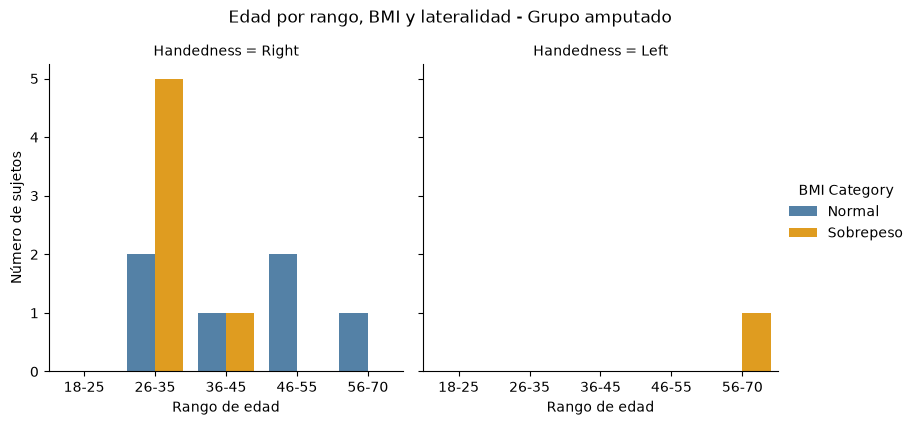

In [20]:
amputated['BMI'] = amputated['Weight'] / (amputated['Height']/100)**2
bins_imc = [0, 18.5, 25, 30, 100]
etiquetas_imc = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
amputated['BMI Category'] = pd.cut(amputated['BMI'], bins=bins_imc, labels=etiquetas_imc)

bins_edad = [17, 25, 35, 45, 55, 70]
etiquetas_edad = ['18-25', '26-35', '36-45', '46-55', '56-70']
amputated['Age Group'] = pd.cut(amputated['Age'], bins=bins_edad, labels=etiquetas_edad)

amputated_plot = amputated.dropna(subset=['BMI Category', 'Age Group']).copy()
amputated_plot['BMI Category'] = amputated_plot['BMI Category'].cat.remove_unused_categories()

g = sns.catplot(
    data=amputated_plot, x='Age Group', hue='BMI Category', col='Handedness',
    kind='count', height=4, aspect=1, palette={'Normal': 'steelblue', 'Sobrepeso': 'orange'}
)
g.set_axis_labels('Rango de edad', 'Número de sujetos')
g.fig.suptitle('Edad por rango, BMI y lateralidad - Grupo amputado', y=1.05)

#### 3.5 Análisis estratificado por base de datos

Al igual que en el grupo intacto, se revisa si la base de datos de origen introduce variaciones visibles en edad, peso o altura. Se muestra primero la comparación simple por base de datos y luego se añade el género como segunda variable; con un total de 13 sujetos, algunas combinaciones bd × género pueden tener muy pocos casos.


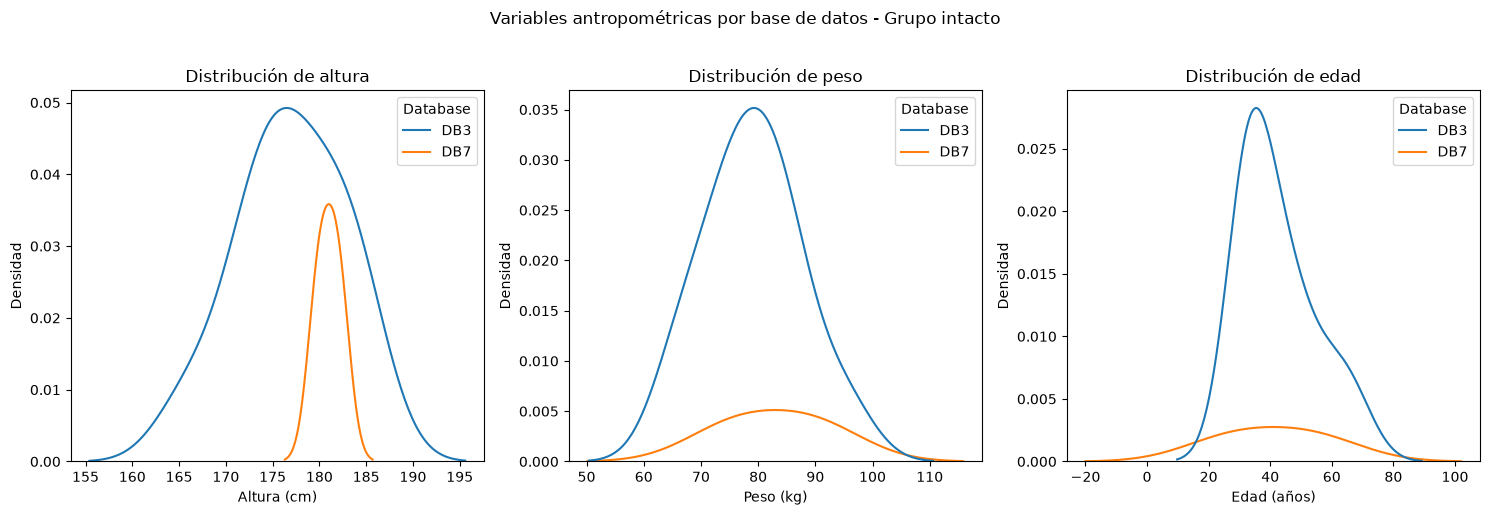

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=amputated, x='Height', hue='Database', ax=axes[0])
axes[0].set_title('Distribución de altura')
axes[0].set_xlabel('Altura (cm)')
axes[0].set_ylabel('Densidad')

sns.kdeplot(data=amputated, x='Weight', hue='Database', ax=axes[1])
axes[1].set_title('Distribución de peso')
axes[1].set_xlabel('Peso (kg)')
axes[1].set_ylabel('Densidad')

sns.kdeplot(data=amputated, x='Age', hue='Database', ax=axes[2])
axes[2].set_title('Distribución de edad')
axes[2].set_xlabel('Edad (años)')
axes[2].set_ylabel('Densidad')

fig.suptitle('Variables antropométricas por base de datos - Grupo intacto', y=1.02)
plt.tight_layout()


##### 3.5.1 Tabla resumen: media y desviación estándar por base de datos

Esta tabla resume media y desviación estándar de edad, peso y altura por base de datos, e incluye explícitamente el número de sujetos (n). Se deja el n visible porque las bases con pocos sujetos pueden mostrar medias poco estables y esto debe advertirse antes de comparar valores entre filas.


In [22]:
resumen_intact = amputated.groupby('Database').agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

,n,Edad_media,Edad_de,Altura_media,Altura_de,Peso_media,Peso_de
Database,,,,,,,
DB3,11,42.4,12.0,176.9,5.7,79.0,8.4
DB7,2,41.0,18.4,181.0,1.4,83.0,9.9


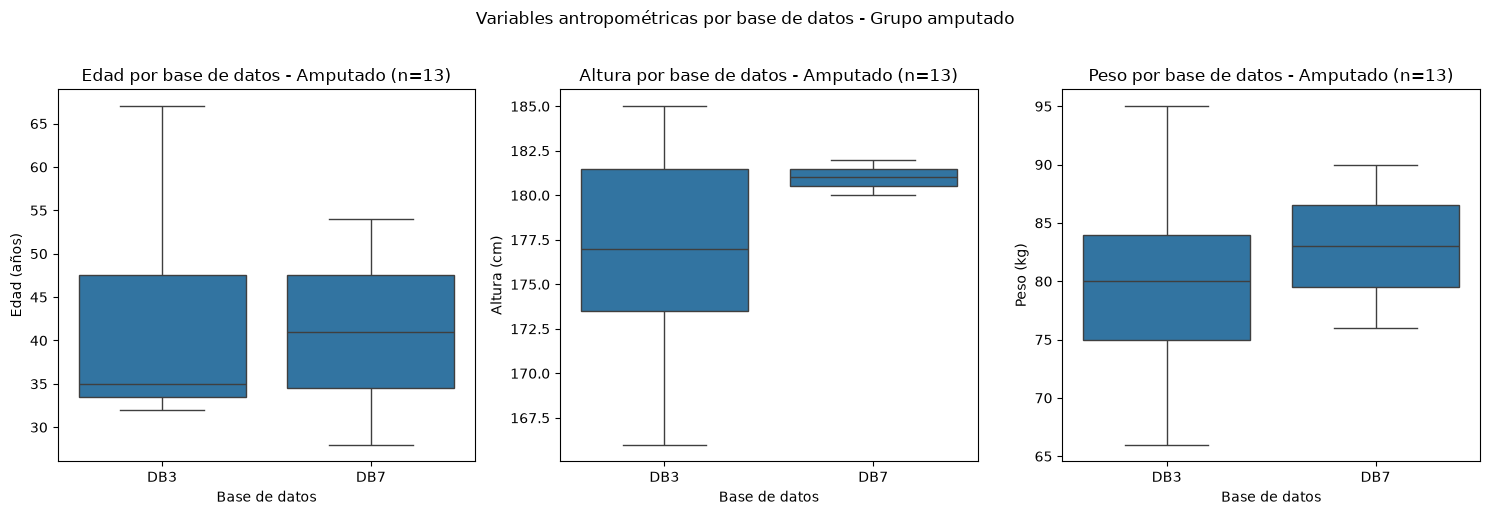

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='Database', y='Age', data=amputated, ax=axes[0])
sns.boxplot(x='Database', y='Height', data=amputated, ax=axes[1])
sns.boxplot(x='Database', y='Weight', data=amputated, ax=axes[2])

unidades = {'Edad': 'años', 'Altura': 'cm', 'Peso': 'kg'}
for ax, titulo in zip(axes, ['Edad', 'Altura', 'Peso']):
    ax.set_title(f'{titulo} por base de datos - Amputado (n=13)')
    ax.set_xlabel('Base de datos')
    ax.set_ylabel(f'{titulo} ({unidades[titulo]})')

fig.suptitle('Variables antropométricas por base de datos - Grupo amputado', y=1.02)
plt.tight_layout()


##### 3.5.2 Tabla resumen: media y desviación estándar por base de datos y género

Esta tabla desglosa la anterior por género dentro de cada base de datos. El objetivo es identificar si existen diferencias de composición entre géneros dentro de cada estudio y verificar si el equilibrio entre categorías es consistente across bases de datos. Algunas bases pueden tener proporciones desbalanceadas de género, lo cual debe considerarse al interpretar comparaciones entre grupos.

In [24]:
resumen_intact = amputated.groupby(['Database', 'Gender']).agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

n  Edad_media  Edad_de  Altura_media  Altura_de  Peso_media  \
Database Gender                                                                 
DB3      Female   1        34.0      NaN         166.0        NaN        68.0   
         Male    10        43.2     12.3         178.0        4.6        80.1   
DB7      Male     2        41.0     18.4         181.0        1.4        83.0   

                 Peso_de  
Database Gender           
DB3      Female      NaN  
         Male        8.0  
DB7      Male        9.9

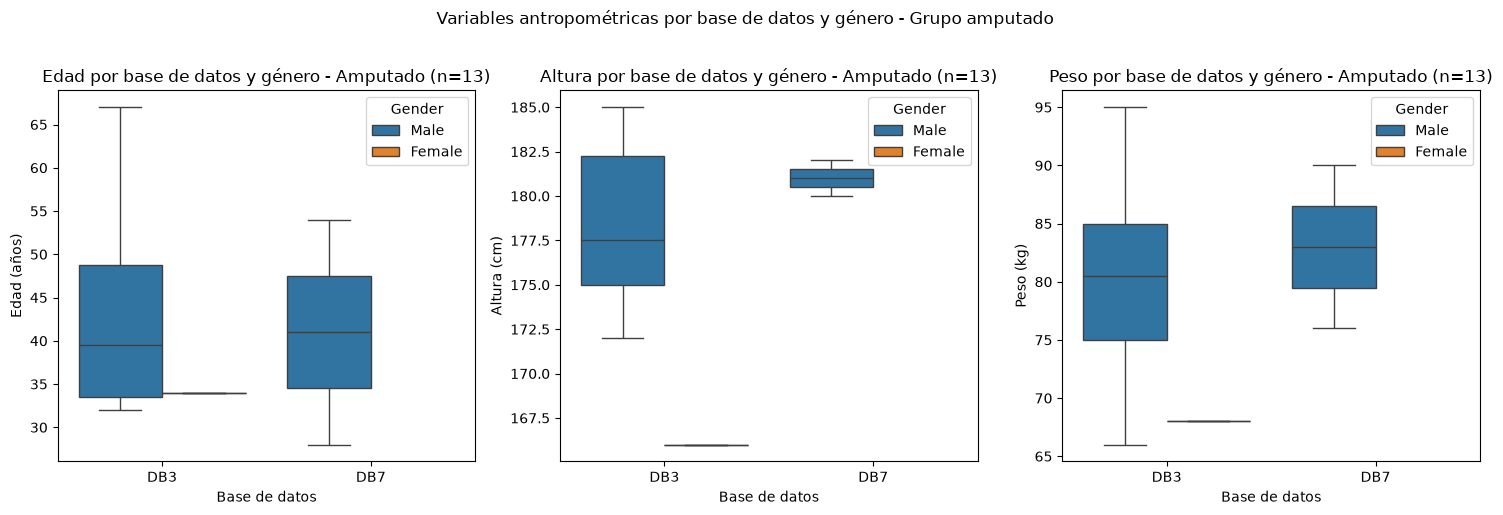

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='Database', y='Age', hue='Gender', data=amputated, ax=axes[0])
sns.boxplot(x='Database', y='Height', hue='Gender', data=amputated, ax=axes[1])
sns.boxplot(x='Database', y='Weight', hue='Gender', data=amputated, ax=axes[2])

unidades = {'Edad': 'años', 'Altura': 'cm', 'Peso': 'kg'}
for ax, titulo in zip(axes, ['Edad', 'Altura', 'Peso']):
    ax.set_title(f'{titulo} por base de datos y género - Amputado (n=13)')
    ax.set_xlabel('Base de datos')
    ax.set_ylabel(f'{titulo} ({unidades[titulo]})')

fig.suptitle('Variables antropométricas por base de datos y género - Grupo amputado', y=1.02)
plt.tight_layout()


##### 3.5.3 Tabla resumen: media y desviación estándar por base de datos y categoría de IMC - Grupo amputado

Esta tabla desglosa las variables antropométricas por categoría de IMC dentro de cada base de datos del grupo amputado. El objetivo es identificar si existen diferencias de composición según el estado nutricional dentro de cada estudio y verificar si la distribución de categorías de IMC es consistente entre bases de datos. Dado el reducido tamaño de muestra (n=13), las cifras deben interpretarse como indicadores exploratorios y no como estimaciones robustas.

In [26]:
resumen_intact = amputated.groupby(['Database', 'BMI Category']).agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

n  Edad_media  Edad_de  Altura_media  Altura_de  \
Database BMI Category                                                    
DB3      Normal        6        41.3     13.4         177.3        7.6   
         Sobrepeso     5        43.6     11.5         176.4        3.0   
DB7      Normal        1        28.0      NaN         180.0        NaN   
         Sobrepeso     1        54.0      NaN         182.0        NaN   

                       Peso_media  Peso_de  
Database BMI Category                       
DB3      Normal              73.3      5.5  
         Sobrepeso           85.8      5.8  
DB7      Normal              76.0      NaN  
         Sobrepeso           90.0      NaN

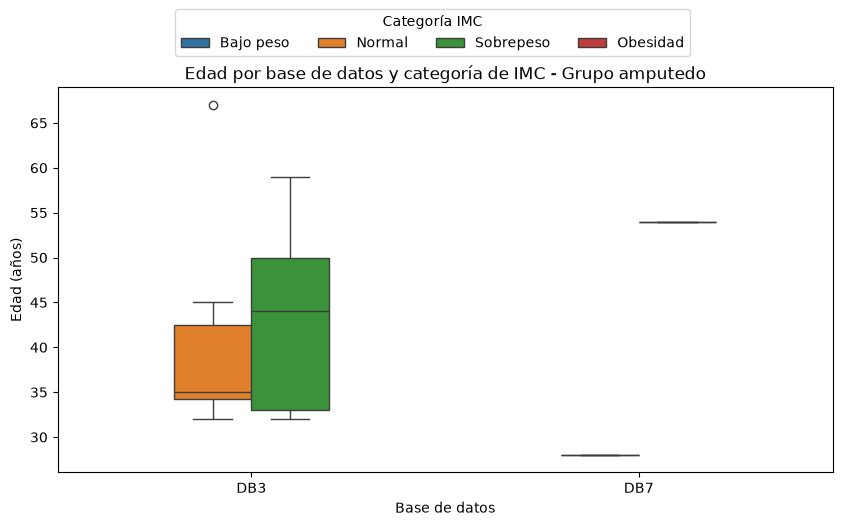

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(x='Database', y='Age', hue='BMI Category', data=amputated, ax=ax)

ax.set_title('Edad por base de datos y categoría de IMC - Grupo amputedo')
ax.set_xlabel('Base de datos')
ax.set_ylabel('Edad (años)')
ax.get_legend().remove()

# Leyenda general única
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Categoría IMC', loc='upper center',
           bbox_to_anchor=(0.5, 1.05), ncol=4)

#### 3.6 Mano dominante y mano amputada

En esta subsección se evalúa cuántos sujetos presentan amputación en su mano dominante. Para ello se cruza la lateralidad reportada (`Handedness`) con la mano afectada (`Hand`). Este contraste permite estimar de forma directa la magnitud de la pérdida funcional sobre el lado dominante.


Text(0, 0.5, 'Número de sujetos')

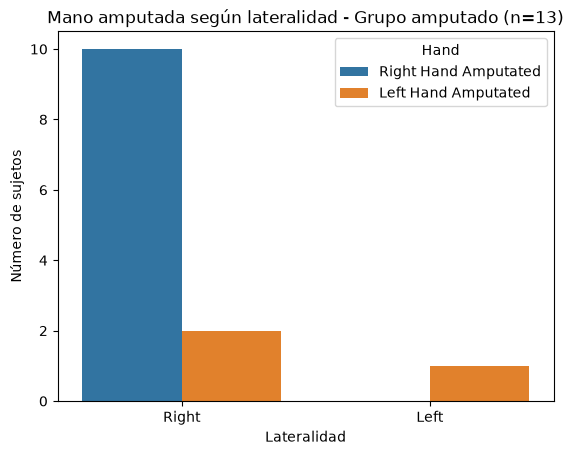

In [29]:
sns.countplot(data=amputated, x='Handedness', hue='Hand')
plt.title('Mano amputada según lateralidad - Grupo amputado (n=13)')
plt.xlabel('Lateralidad')
plt.ylabel('Número de sujetos')


#### 3.7 Indicadores clínicos

En esta sección se describen variables clínicas clave del grupo amputado. El objetivo es complementar el perfil demográfico y antropométrico con medidas de percepción, funcionalidad y evolución clínica tras la amputación.


##### 3.7.1 Sensación de miembro fantasma

Se visualiza la intensidad reportada de la sensación de miembro fantasma para entender la variabilidad de esta percepción en la muestra amputada.

* La sensación de miembro fantasma es la percepción de que una extremidad amputada aún sigue ahí.


Text(0, 0.5, 'Número de sujetos')

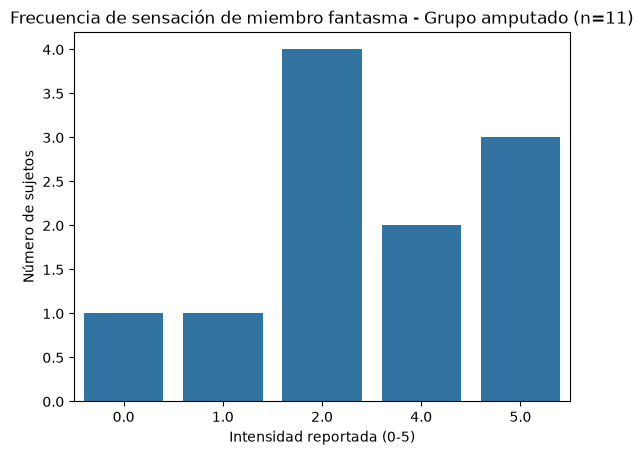

In [30]:
sns.countplot(x='Phantom Limb Sensation Intensity', data=amputated)
plt.title('Frecuencia de sensación de miembro fantasma - Grupo amputado (n=11)')
plt.xlabel('Intensidad reportada (0-5)')
plt.ylabel('Número de sujetos')


##### 3.7.2 Puntuación DASH

La puntuación DASH mide el nivel de discapacidad del brazo, hombro y mano. Se calcula a partir de 30 preguntas mediante la siguiente fórmula:

$$
\text{DASH} = \left[\left(\frac{\text{Suma de respuestas}}{30}\right) - 1\right] \times 25
$$

El resultado varía de 0, que indica ausencia de discapacidad, a 100, que representa la máxima discapacidad.


Text(0, 0.5, 'Número de sujetos')

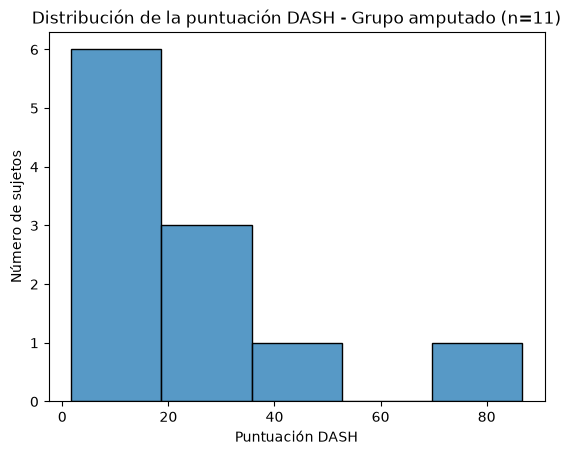

In [31]:
sns.histplot(amputated['DASH Score'])
plt.title('Distribución de la puntuación DASH - Grupo amputado (n=11)')
plt.xlabel('Puntuación DASH')
plt.ylabel('Número de sujetos')


##### 3.7.3 Años transcurridos desde la amputación

Esta variable resume el tiempo de evolución clínica de cada sujeto desde el evento de amputación. Su distribución ayuda a contextualizar la fase de adaptación de la muestra.


Text(0, 0.5, 'Número de sujetos')

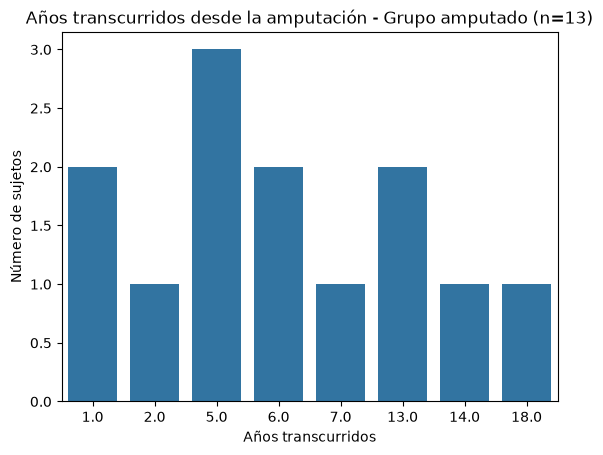

In [32]:
sns.countplot(x='Years passed by the amputation', data=amputated)
plt.title('Años transcurridos desde la amputación - Grupo amputado (n=13)')
plt.xlabel('Años transcurridos')
plt.ylabel('Número de sujetos')


##### 3.7.4 Porcentaje de antebrazo remanente

El porcentaje de antebrazo remanente describe la condición anatómica residual del miembro superior.

El porcentaje de antebrazo remanente se calcula como:

$$
\text{Porcentaje de antebrazo remanente} =
\frac{\text{Longitud del muñón}}{\text{Longitud original del antebrazo}} \times 100
$$

Donde:

- **Longitud del muñón**: distancia desde el olécranon (punta del codo) hasta el extremo distal del muñón.
- **Longitud original del antebrazo**: distancia desde el olécranon hasta la estiloides del radio (aproximadamente donde inicia la mano).

Esta información es relevante para interpretar la variabilidad funcional entre sujetos amputados.


Text(0, 0.5, 'Número de sujetos')

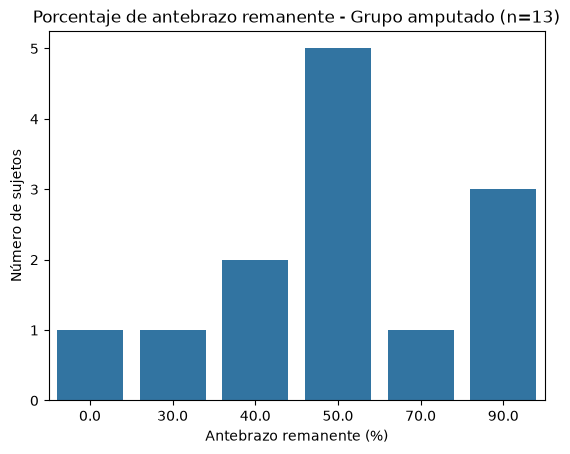

In [33]:
sns.countplot(x='Remaining Forearm (%)', data=amputated)
plt.title('Porcentaje de antebrazo remanente - Grupo amputado (n=13)')
plt.xlabel('Antebrazo remanente (%)')
plt.ylabel('Número de sujetos')


##### 3.7.5 Uso de prótesis

Se describe cuántos años reporta cada sujeto usando prótesis cosmética, cinemática o mioeléctrica. Un valor de 0 años se interpreta como que el sujeto no ha usado ese tipo de prótesis.

Sujetos que han usado cada tipo de prótesis (al menos 1 año):
Use of cosmetic prosthesis       1
Use of kinematic prosthesis      7
Use of myoelectric prosthesis    7
dtype: int64


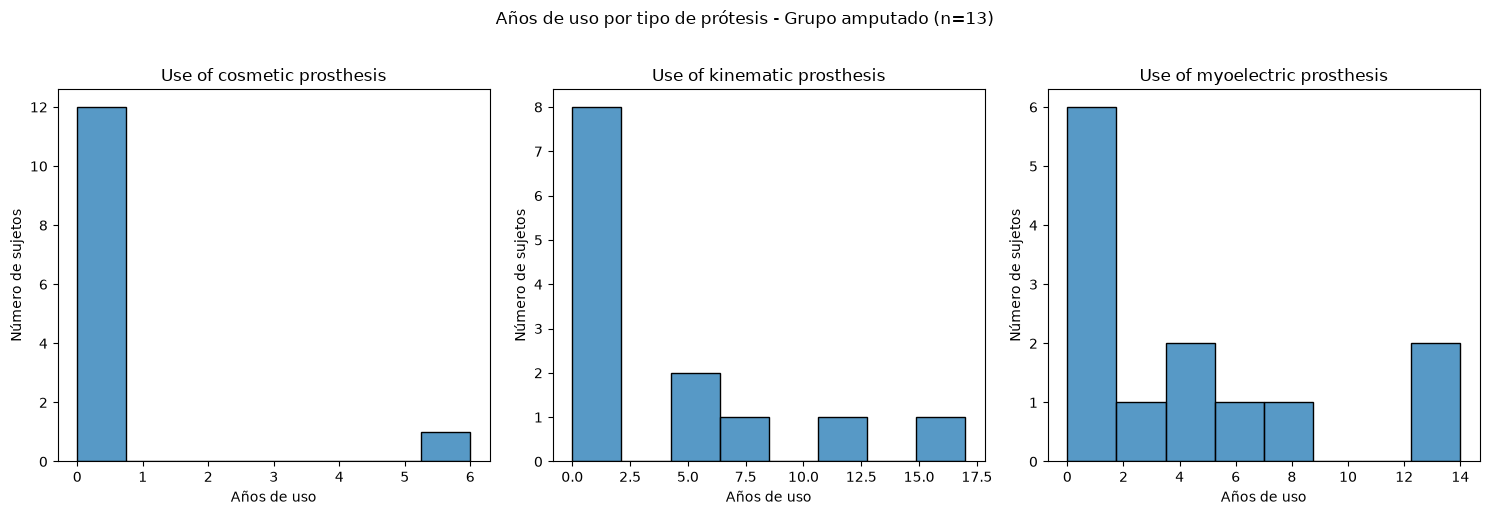

In [34]:
prostheses = ['Use of cosmetic prosthesis (Years)', 'Use of kinematic prosthesis (Years)', 'Use of myoelectric prosthesis (Years)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, prostheses):
    sns.histplot(amputated[col], kde=False, ax=ax, bins=8)
    ax.set_title(col.replace(' (Years)', ''))
    ax.set_xlabel('Años de uso')
    ax.set_ylabel('Número de sujetos')
fig.suptitle('Años de uso por tipo de prótesis - Grupo amputado (n=13)', y=1.02)
plt.tight_layout()

uso = (amputated[prostheses] > 0).sum()
uso.index = [c.replace(' (Years)', '') for c in uso.index]
print('Sujetos que han usado cada tipo de prótesis (al menos 1 año):')
print(uso)

En conjunto, los indicadores clínicos de esta sección muestran la heterogeneidad del grupo amputado en percepción, funcionalidad y evolución. Estas variables aportan contexto para interpretar con mayor precisión los análisis comparativos y las etapas posteriores de procesamiento de señales.

#### 3.8 Relaciones entre variables numéricas y clínicas

Se amplía la matriz de correlación para incluir, además de edad, altura, peso e IMC, las variables clínicas del grupo amputado. Esto ayuda a identificar relaciones clínicamente relevantes, como si el tiempo transcurrido desde la amputación se asocia con menor discapacidad reportada.

Text(0.5, 1.0, 'Correlación entre variables numéricas y clínicas - Grupo amputado (n=13)')

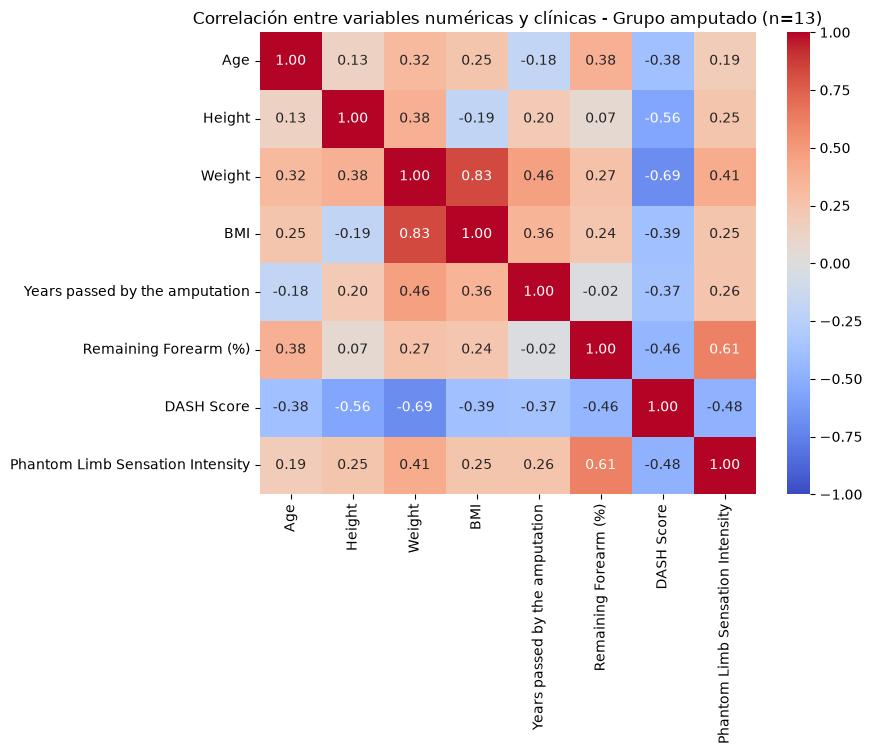

In [35]:
numeric_vars_amp = ['Age', 'Height', 'Weight', 'BMI', 'Years passed by the amputation',
                     'Remaining Forearm (%)', 'DASH Score', 'Phantom Limb Sensation Intensity']
corr_amputated = amputated[numeric_vars_amp].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_amputated, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas y clínicas - Grupo amputado (n=13)')

##### 3.8.1 Puntuación DASH y años desde la amputación

Se examina de forma puntual si la discapacidad reportada disminuye con el tiempo de adaptación tras la amputación, coloreando cada punto según la causa de amputación para ver si ese patrón se explica, en parte, por el tipo de causa.

Text(0, 0.5, 'Puntuación DASH')

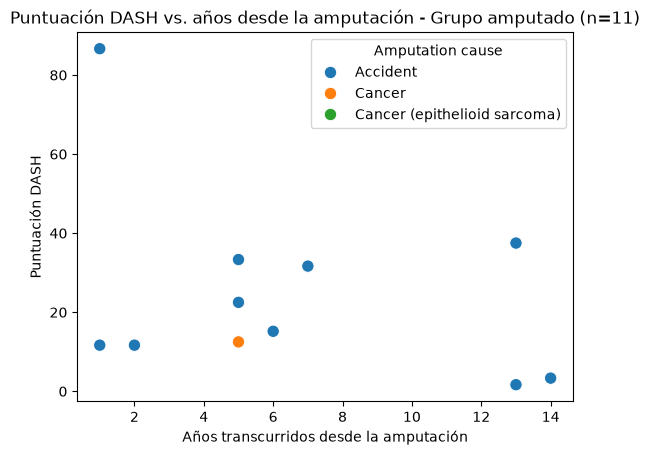

In [36]:
sns.scatterplot(data=amputated, x='Years passed by the amputation', y='DASH Score', hue='Amputation cause', s=80)
plt.title('Puntuación DASH vs. años desde la amputación - Grupo amputado (n=11)')
plt.xlabel('Años transcurridos desde la amputación')
plt.ylabel('Puntuación DASH')

#### 3.9 Indicadores clínicos según causa de amputación

La causa de amputación se describió de forma aislada en la sección 3.2, pero nunca se cruzó con los indicadores clínicos. Aquí se revisa si la puntuación DASH, el porcentaje de antebrazo remanente y la intensidad de sensación de miembro fantasma varían según la causa.

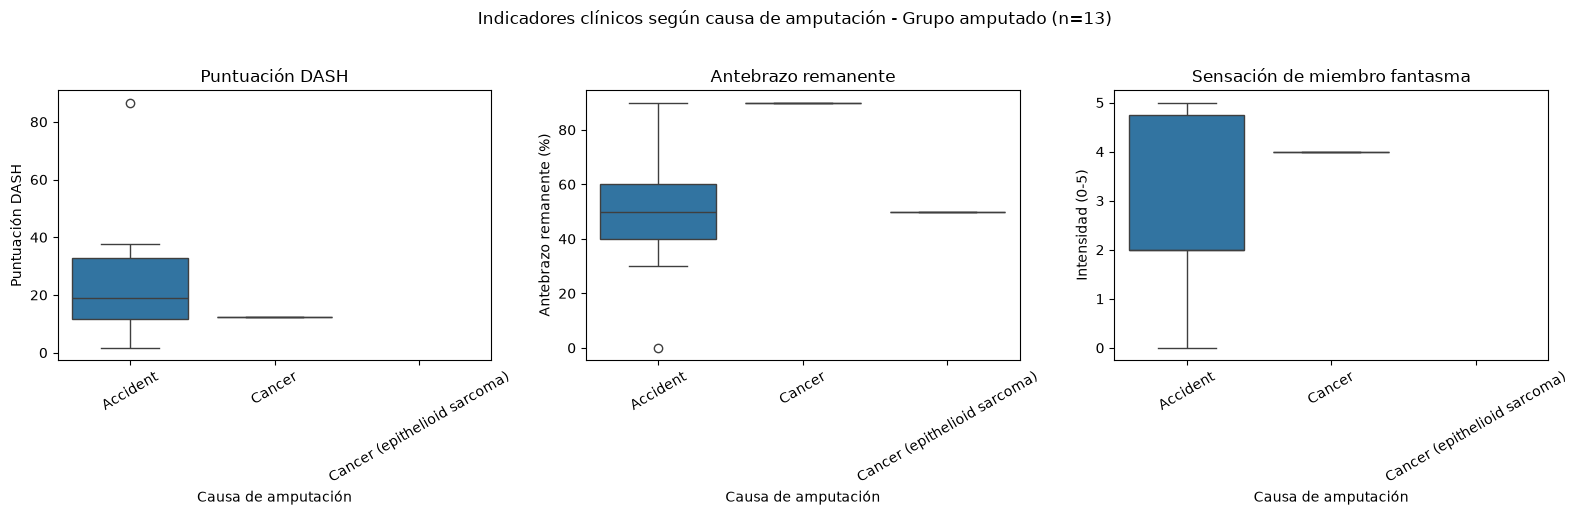

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='Amputation cause', y='DASH Score', data=amputated, ax=axes[0])
axes[0].set_title('Puntuación DASH')
axes[0].set_xlabel('Causa de amputación')
axes[0].set_ylabel('Puntuación DASH')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(x='Amputation cause', y='Remaining Forearm (%)', data=amputated, ax=axes[1])
axes[1].set_title('Antebrazo remanente')
axes[1].set_xlabel('Causa de amputación')
axes[1].set_ylabel('Antebrazo remanente (%)')
axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(x='Amputation cause', y='Phantom Limb Sensation Intensity', data=amputated, ax=axes[2])
axes[2].set_title('Sensación de miembro fantasma')
axes[2].set_xlabel('Causa de amputación')
axes[2].set_ylabel('Intensidad (0-5)')
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle('Indicadores clínicos según causa de amputación - Grupo amputado (n=13)', y=1.02)
plt.tight_layout()